In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pakistans-ecommerce-dataset/Pakistan Largest Ecommerce Dataset.csv


In [2]:
df = pd.read_csv(
    '/kaggle/input/pakistans-ecommerce-dataset/Pakistan Largest Ecommerce Dataset.csv',
    low_memory=False
)


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(1048575, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                 

## Data Cleaning 

Initial Dataset Shape: (1048575, 26)
Completely null columns: Index(['Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24',
       'Unnamed: 25'],
      dtype='object')


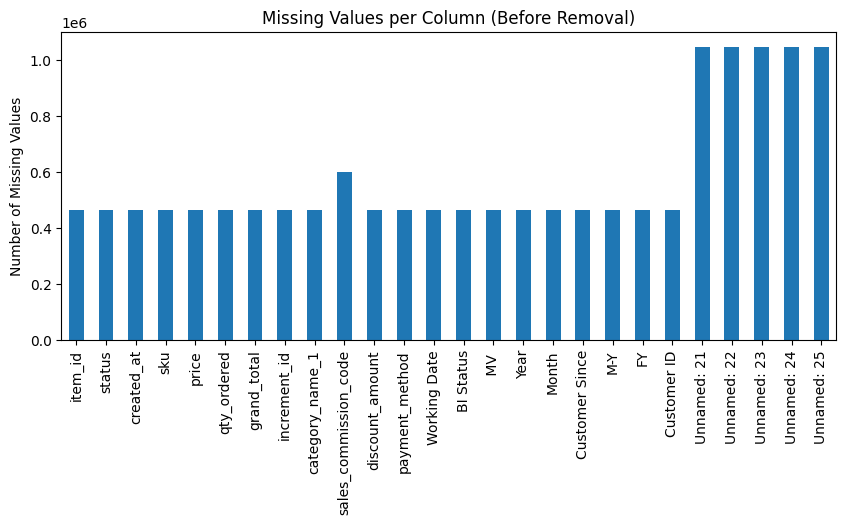

After removing completely null columns: (1048575, 21)
Duplicate rows count: 464050
After removing duplicate rows: (584525, 21)
created_at is a duplicate of Working Date
After removing redundant columns: (584525, 15)
After removing rows with missing values: (584334, 15)


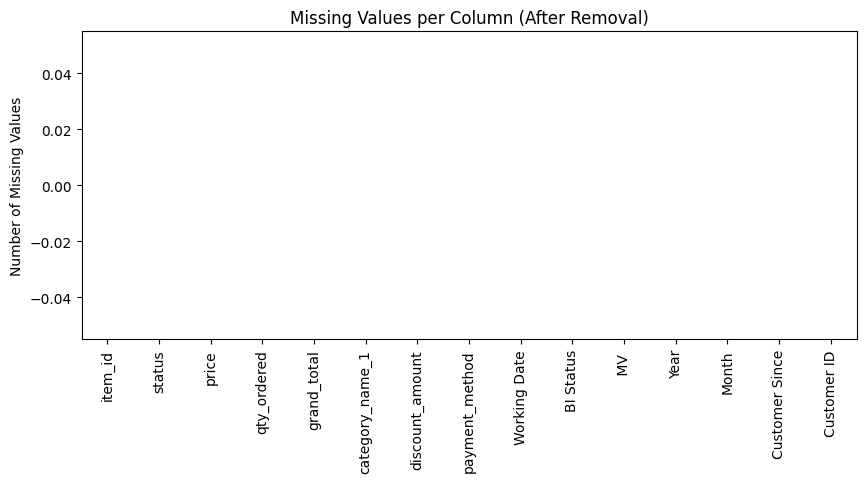

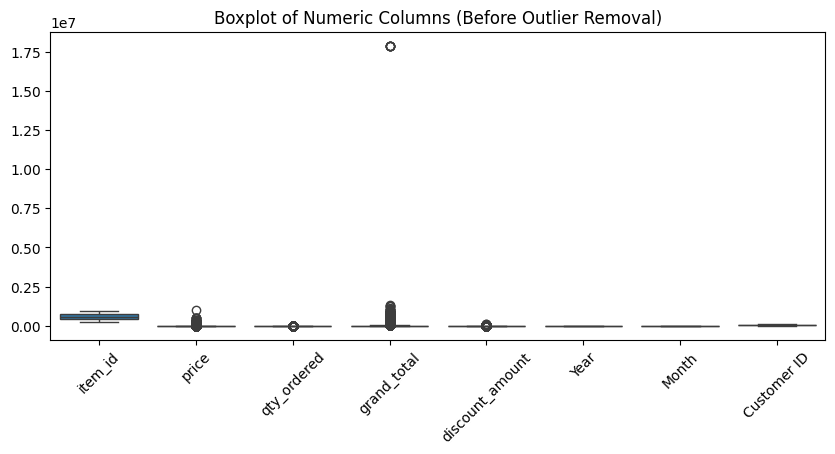

After handling outliers: (299561, 15)


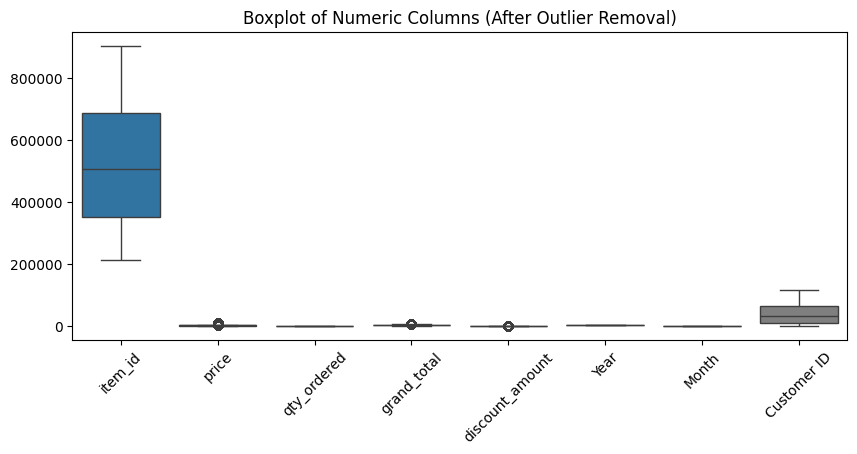

Final dataset shape: (299561, 15)


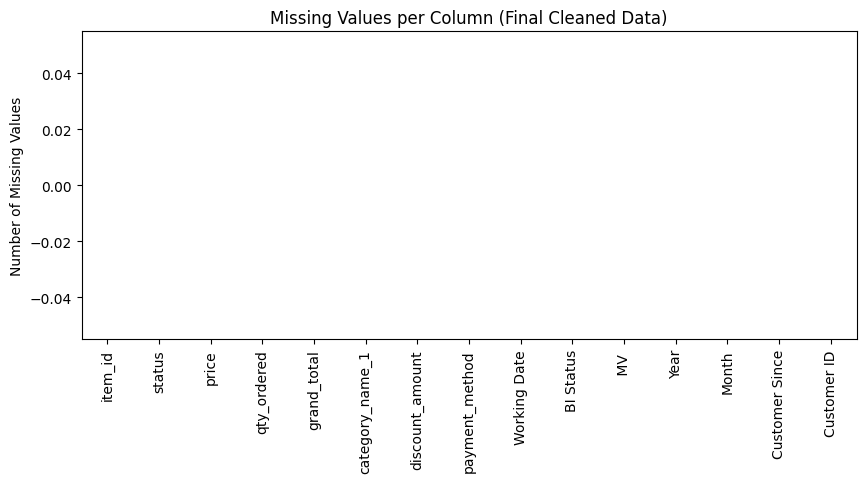

<class 'pandas.core.frame.DataFrame'>
Index: 299561 entries, 0 to 584519
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   item_id          299561 non-null  float64       
 1   status           299561 non-null  object        
 2   price            299561 non-null  float64       
 3   qty_ordered      299561 non-null  float64       
 4   grand_total      299561 non-null  float64       
 5   category_name_1  299561 non-null  object        
 6   discount_amount  299561 non-null  float64       
 7   payment_method   299561 non-null  object        
 8   Working Date     299561 non-null  datetime64[ns]
 9   BI Status        299561 non-null  object        
 10   MV              299561 non-null  object        
 11  Year             299561 non-null  float64       
 12  Month            299561 non-null  float64       
 13  Customer Since   299561 non-null  object        
 14  Customer ID      299561 n

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Initial dataset info
# -------------------------
print("Initial Dataset Shape:", df.shape)

# -------------------------
# 1. Checking for completely null columns
# -------------------------
null_cols = df.columns[df.isnull().all()]
print("Completely null columns:", null_cols)

# Bar chart for missing values before removal
plt.figure(figsize=(10,4))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column (Before Removal)")
plt.ylabel("Number of Missing Values")
plt.show()

# -------------------------
# 2. Removing completely null columns
# -------------------------
df = df.drop(columns=null_cols)
print("After removing completely null columns:", df.shape)

# -------------------------
# 3. Removing duplicate rows
# -------------------------
dup_count = df.duplicated().sum()
print("Duplicate rows count:", dup_count)
df = df.drop_duplicates()
print("After removing duplicate rows:", df.shape)

# -------------------------
# 4. Checking for duplicate columns
# -------------------------
for i in range(len(df.columns)):
    for j in range(i+1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            print(f"{df.columns[i]} is a duplicate of {df.columns[j]}")

# -------------------------
# 5. Removing redundant columns
# -------------------------
redundant_cols = ['created_at', 'sku', 'MV', 'M-Y', 'FY', 'increment_id', 'sales_commission_code']
for col in redundant_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
print("After removing redundant columns:", df.shape)

# -------------------------
# 6. Handling remaining missing values
# -------------------------
df = df.dropna()
print("After removing rows with missing values:", df.shape)

# Bar chart for missing values after removal
plt.figure(figsize=(10,4))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column (After Removal)")
plt.ylabel("Number of Missing Values")
plt.show()

# -------------------------
# 7. Converting date column to datetime
# -------------------------
df['Working Date'] = pd.to_datetime(df['Working Date'], errors='coerce')

# -------------------------
# 8. Boxplot of all numeric columns before outlier removal
# -------------------------
numeric_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(10,4))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Columns (Before Outlier Removal)")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# 9. Handling outliers using IQR
# -------------------------
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]
print("After handling outliers:", df.shape)

# -------------------------
# 10. Boxplot of all numeric columns after outlier removal
# -------------------------
plt.figure(figsize=(10,4))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Columns (After Outlier Removal)")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# 11. Final check for missing values
# -------------------------
df = df.dropna()
print("Final dataset shape:", df.shape)

# Final bar chart for missing values
plt.figure(figsize=(10,4))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column (Final Cleaned Data)")
plt.ylabel("Number of Missing Values")
plt.show()

# -------------------------
# 12. Final dataframe info
# -------------------------
print(df.info())
print(df.isnull().sum())


/tmp/ipykernel_17/3975411366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_rates.index, y=cancel_rates.values, palette="RdYlGn_r", ax=ax, zorder=3)
/tmp/ipykernel_17/3975411366.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


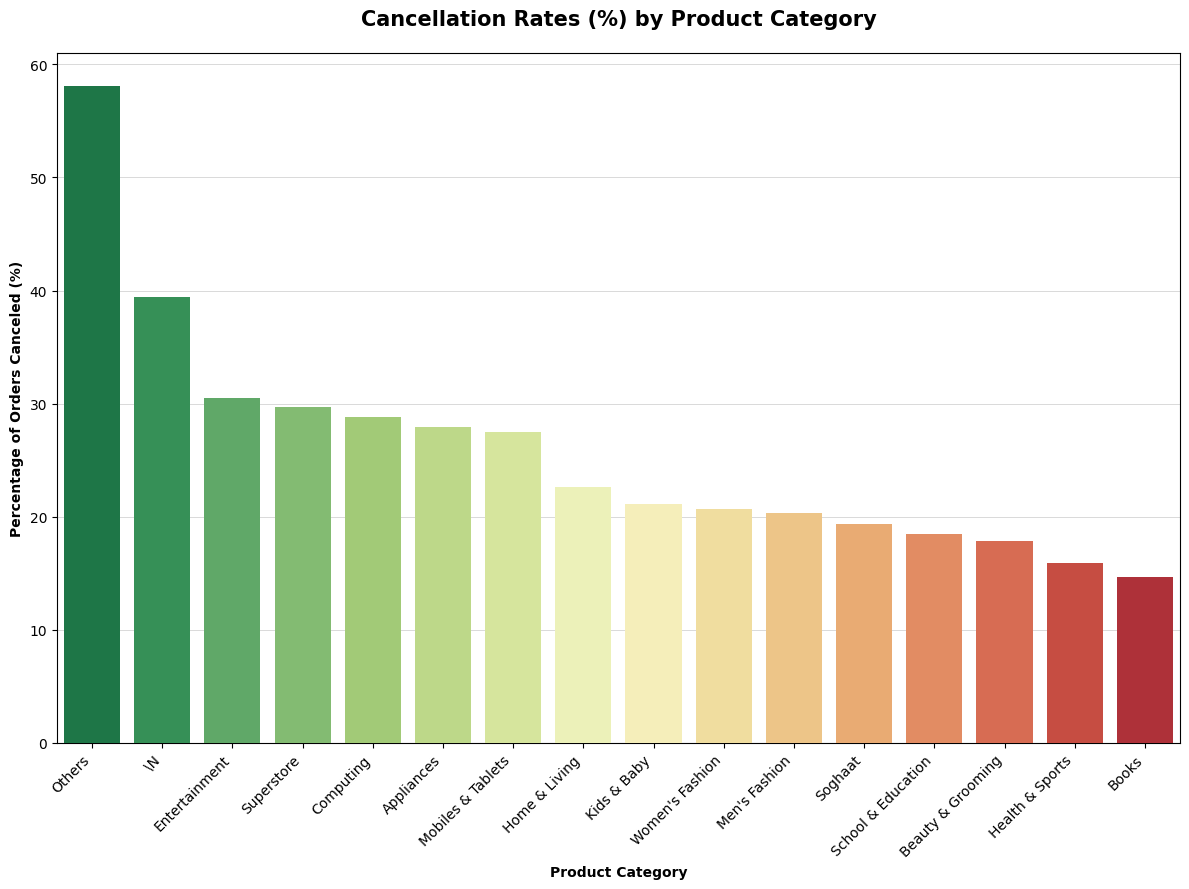

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic setup
fig, ax = plt.subplots(figsize=(12, 9))

# Calculating cancellation rates
cancel_rates = df.groupby('category_name_1')['status'].apply(lambda x: (x == 'canceled').mean() * 100).sort_values(ascending=False)

# Vertical Bar Chart (Categories on X, % on Y)
sns.barplot(x=cancel_rates.index, y=cancel_rates.values, palette="RdYlGn_r", ax=ax, zorder=3)

# Grid and Labeling (Solid light gray background grid)
ax.set_axisbelow(True)
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.6, zorder=0)

ax.set_title('Cancellation Rates (%) by Product Category', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Product Category', fontweight='bold')
ax.set_ylabel('Percentage of Orders Canceled (%)', fontweight='bold')

# Rotating X-labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

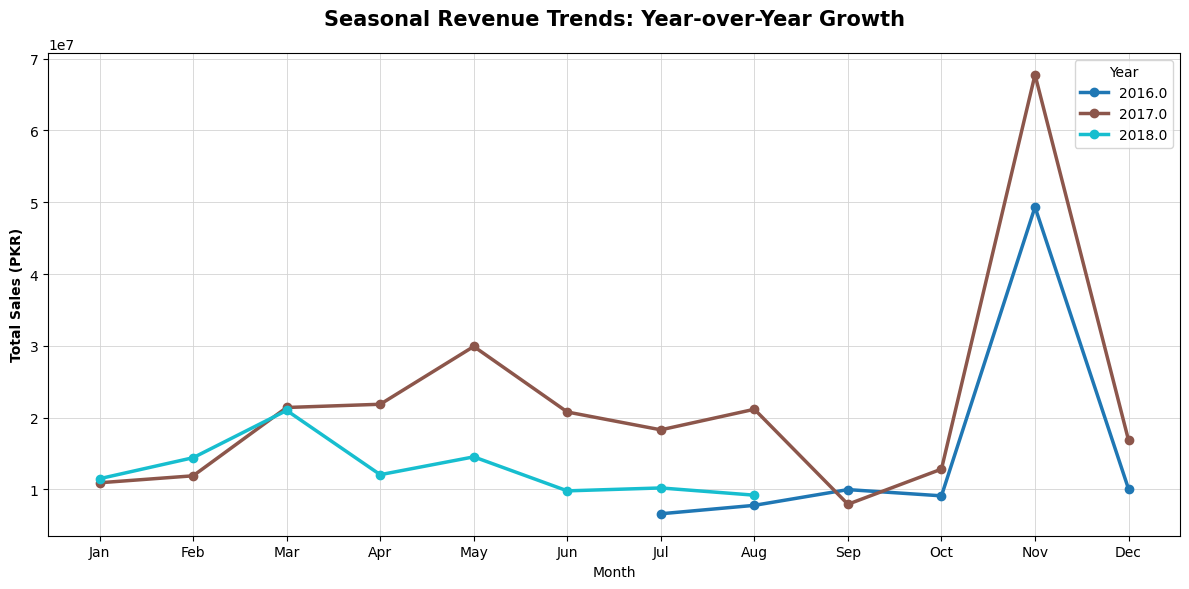

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot_growth = df.groupby(['Year', 'Month'])['grand_total'].sum().unstack(level=0)

# Multi-line plot (Truthfulness: continuous time representation)
pivot_growth.plot(marker='o', linewidth=2.5, ax=ax, colormap='tab10', zorder=3)

# Grid and Labeling
ax.set_axisbelow(True)
ax.grid(color='lightgray', linestyle='-', linewidth=0.6, zorder=0)
ax.set_title('Seasonal Revenue Trends: Year-over-Year Growth', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('Total Sales (PKR)', fontweight='bold')
ax.legend(title='Year', frameon=True)

plt.tight_layout()
plt.show()

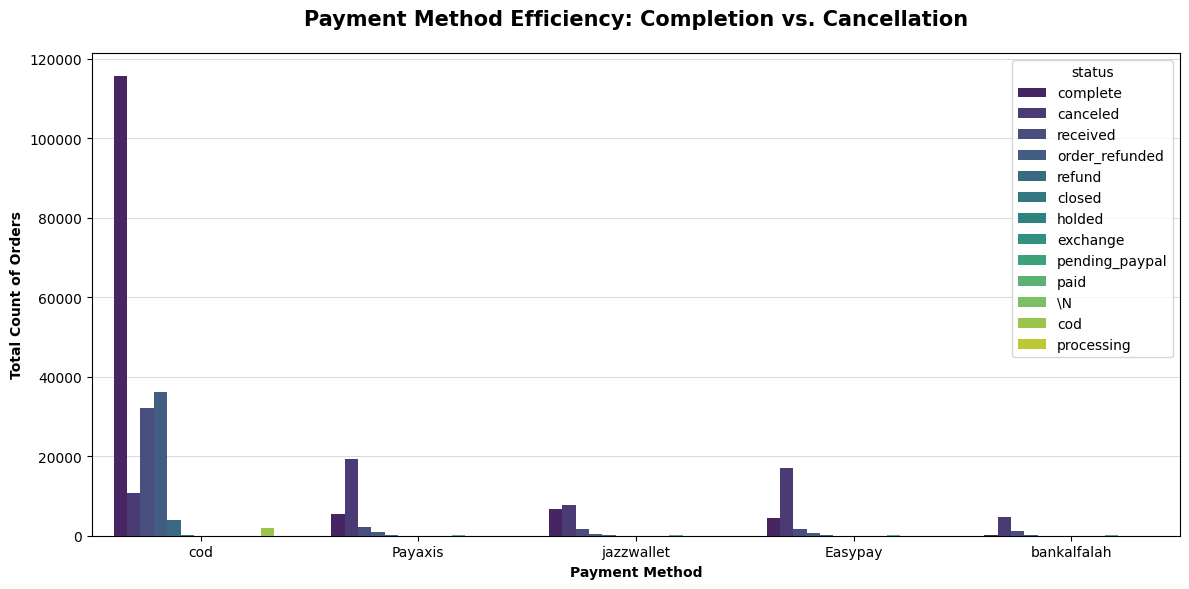

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
top_methods = df['payment_method'].value_counts().head(5).index
pmt_status = df[df['payment_method'].isin(top_methods)]

# Grouped Bar Chart (Insightful comparison of sub-groups)
sns.countplot(data=pmt_status, x='payment_method', hue='status', palette="viridis", ax=ax, zorder=3)

# Grid and Labeling
ax.set_axisbelow(True)
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.6, zorder=0)
ax.set_title('Payment Method Efficiency: Completion vs. Cancellation', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Total Count of Orders', fontweight='bold')
ax.set_xlabel('Payment Method', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_17/726311780.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=percentages, palette=colors, ax=ax, zorder=3)


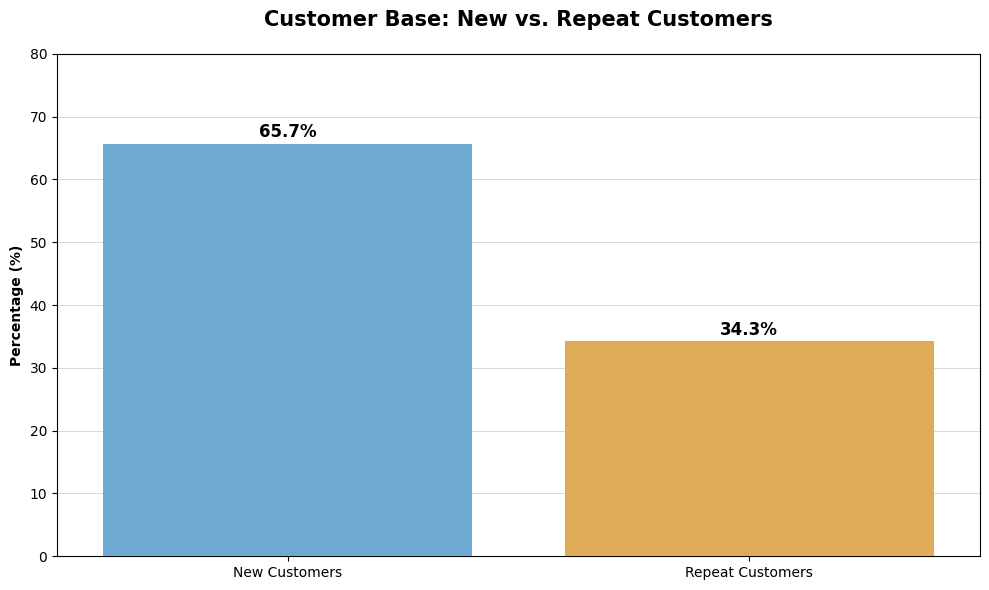

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic setup
fig, ax = plt.subplots(figsize=(10, 6))

# Data for New vs Repeat Customers (based on the provided statistics)
labels = ['New Customers', 'Repeat Customers']
percentages = [65.7, 34.3]
colors = ['#5dade2', '#f5b041'] # Professional Blue and Orange

# Vertical Bar Chart (Truthful and Functional)
sns.barplot(x=labels, y=percentages, palette=colors, ax=ax, zorder=3)

# Adding Percentage Labels on top of bars for clarity
for i, p in enumerate(percentages):
    ax.annotate(f'{p}%', (i, p + 1), ha='center', fontsize=12, fontweight='bold')

# Grid and Labeling (Solid light gray background grid)
ax.set_axisbelow(True)
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.6, zorder=0)

ax.set_title('Customer Base: New vs. Repeat Customers', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_ylim(0, 80) # Giving space for the labels

plt.tight_layout()
plt.show()

/tmp/ipykernel_17/3837133689.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pmt.index, y=top_pmt.values, palette="Blues_r", ax=ax, zorder=3)


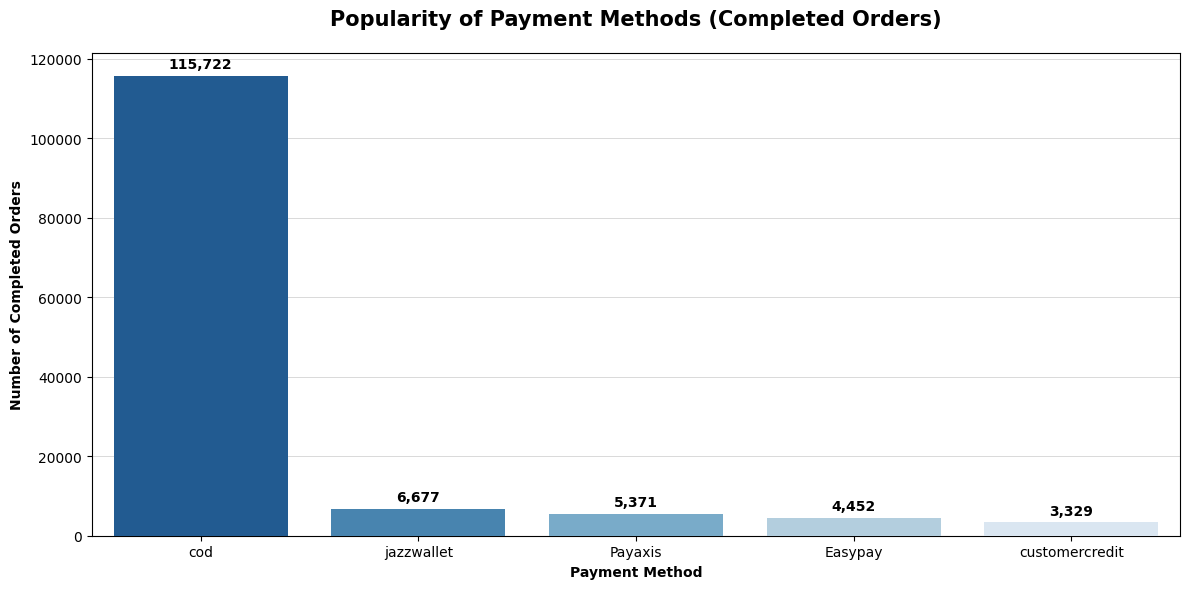

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic setup
fig, ax = plt.subplots(figsize=(12, 6))

# Filtering only 'completed' orders for top payment methods
completed_orders = df[df['status'] == 'complete']
top_pmt = completed_orders['payment_method'].value_counts().head(5)

# Vertical Bar Chart (Truthful and Functional)
sns.barplot(x=top_pmt.index, y=top_pmt.values, palette="Blues_r", ax=ax, zorder=3)

# Adding labels on top of bars
for i, v in enumerate(top_pmt.values):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Grid and Labeling (Solid light gray background grid)
ax.set_axisbelow(True)
ax.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.6, zorder=0)

ax.set_title('Popularity of Payment Methods (Completed Orders)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Payment Method', fontweight='bold')
ax.set_ylabel('Number of Completed Orders', fontweight='bold')

plt.tight_layout()
plt.show()

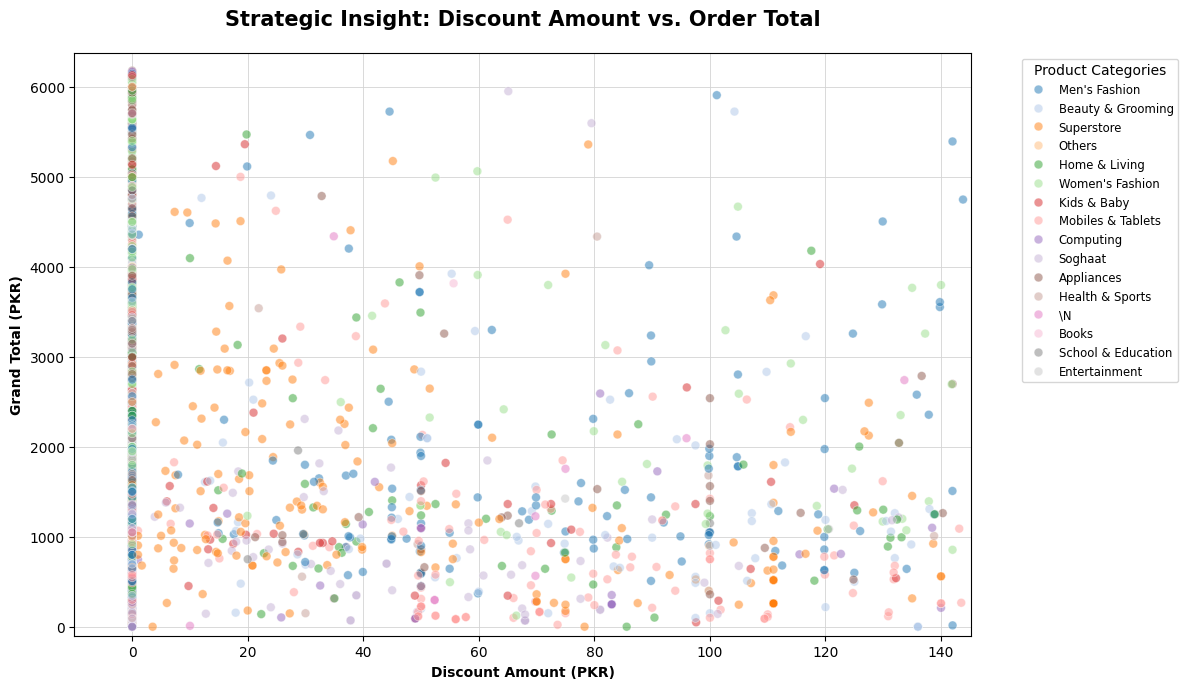

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic setup
fig, ax = plt.subplots(figsize=(12, 7))

# We sample the data to avoid "over-plotting" where dots overlap too much
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

# Scatter Plot (Using 'alpha' for transparency to show density)
# The colors help identify which categories are getting specific discounts
sns.scatterplot(data=sample_df, x='discount_amount', y='grand_total', 
                hue='category_name_1', alpha=0.5, s=40, palette='tab20', ax=ax, zorder=3)

# --- ACCURACY FIX: Quantile Scaling ---
# We set limits at the 99th percentile to zoom into where the data actually is.
# This prevents 1 or 2 outliers from ruining the visualization.
x_limit = sample_df['discount_amount'].quantile(0.99)
y_limit = sample_df['grand_total'].quantile(0.99)
ax.set_xlim(-10, x_limit * 1.1)
ax.set_ylim(-100, y_limit * 1.1)

# Aesthetic Grid (Solid, light gray, and in the background)
ax.set_axisbelow(True)
ax.grid(color='lightgray', linestyle='-', linewidth=0.6, zorder=0)

ax.set_title('Strategic Insight: Discount Amount vs. Order Total', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Discount Amount (PKR)', fontweight='bold')
ax.set_ylabel('Grand Total (PKR)', fontweight='bold')

# Moving the legend outside so it doesn't block the dots
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Product Categories", fontsize='small')

plt.tight_layout()
plt.show()